# Лабораторная работа 6

Тема: **Оптимизация и скорость сходимости: шаг обучения и выбор оптимизатора**  
Цель: на одной и той же модели и датасете (MNIST + простой MLP) **экспериментально** исследовать, как ведут себя разные значения `learning_rate` и разные оптимизаторы (SGD, SGD+Momentum, Adam), и сформулировать свои практические правила выбора.

> Этот ноутбук предназначен именно для вашей самостоятельной работы.  
> Его структура и код - каркас, а содержание (графики, комментарии, выводы) должны отражать **ваши эксперименты и ваш стиль объяснения**.
> Если вы попытаетесь автоматически сгенерировать текст целиком, это будет заметно по общей, оторванной от ваших графиков формулировке.


## 1. Ваши ожидания до экспериментов

Прежде чем смотреть на реальные кривые, зафиксируйте, что вы **ожидаете** увидеть.

Ответьте своими словами:
1. Что, по вашему интуитивному ощущению, происходит с обучением при **очень маленьком** шаге (`lr`): по loss, по времени сходимости, по точности?  
2. Что может пойти не так при **слишком большом** шаге (`lr`), если смотреть на графики loss/accuracy?  
3. Чем вы ожидаете, что будет отличаться поведение **SGD**, **SGD с momentum** и **Adam** на задаче вроде MNIST (скорость сходимости, чувствительность к выбору lr, «рывки» на графиках и т.п.)?

Напишите ответы в свободной форме (6–10 предложений). Важно, чтобы это были именно ваши формулировки, а не пересказ учебника.


In [ ]:
expectations_text = """Если шаг обучения (lr) будет очень маленьким, я ожидаю, что процесс превратится в "черепаший бег": лосс будет падать крайне медленно,
а за отведенные 5–10 эпох точность может вообще не подняться выше случайного угадывания. Время сходимости в таком случае стремится к бесконечности.
В обратной ситуации - при слишком большом шаге - я боюсь увидеть на графиках хаос: лосс может резко взлетать вверх (вплоть до появления NaN) или бесконечно осциллировать, так как модель просто "перепрыгивает" через минимум.

Что касается оптимизаторов, то мой фаворит - Adam. Кажется, что он будет самым плавным и быстрым за счет адаптивности.
От обычного SGD я жду самых дерганых графиков и высокой чувствительности к настройкам - скорее всего, придется долго подбирать lr, чтобы он вообще "завелся".
Momentum должен стать чем-то средним: я ожидаю, что он сгладит рывки SGD и поможет быстрее проскочить участки, где градиент маленький, за счет накопленной "инерции""""
print(expectations_text)

## 2. Импорт библиотек и настройка среды

Здесь всё стандартно:
- импорт PyTorch, torchvision и вспомогательных библиотек;
- фиксация `seed` (одно число, которое вы сможете назвать на защите);
- определение устройства (`cpu` или `cuda`).


In [2]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# ВАШ ЛИЧНЫЙ SEED (можете выбрать любое число, но потом не меняйте его без причины)
MY_SEED = 11
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

Устройство: cpu
MY_SEED = 11


## 3. Данные MNIST и DataLoader

Используем набор рукописных цифр MNIST.  
Ваша задача:
- задать трансформации (как минимум `ToTensor` + нормализация);
- загрузить обучающую и тестовую части;
- создать `DataLoader` с разумным `batch_size`.

Размер батча вы выбираете сами (например, 64 или 128), главное потом объяснить выбор по-человечески: чем он удобен именно для этой работы.


In [3]:
batch_size = 64  # Выбрано 64 как баланс между скоростью обучения и зашумленностью градиента

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("train size =", len(train_dataset))
print("test size  =", len(test_dataset))
print("batch_size =", batch_size)

100%|██████████| 9.91M/9.91M [00:01<00:00, 6.20MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 225kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.10MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.39MB/s]

train size = 60000
test size  = 10000
batch_size = 64


Если вы хотите для спокойствия посмотреть на пару примеров изображений - можете добавить сюда небольшой блок визуализации (по образцу ЛР4–5). Это не обязательно, но иногда помогает ощутить задачу глазами.


## 4. Модель (фиксированная для всех экспериментов)

Чтобы сравнение оптимизаторов и `learning_rate` было честным, архитектура модели должна оставаться **одна и та же** во всех прогонах.

Возьмём простой MLP:
- вход: 28×28 → разворачиваем в вектор длины 784;
- два скрытых слоя с ReLU (например, 256 и 128 нейронов);
- выход: 10 логитов (по одному на цифру 0–9).

Эту архитектуру **не меняем** в рамках лабораторной (если измените - **обязательно явно зафиксируйте это в отчёте**).


In [4]:
class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)

print(SimpleMLP())

SimpleMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


## 5. Общие функции обучения и оценки

Напишем функции `train_one_epoch` и `evaluate`.  
Их вы использовали в прошлых работах; сейчас они понадобятся, чтобы собирать **историю** обучения для разных конфигураций.


In [5]:
criterion = nn.CrossEntropyLoss()

def train_one_epoch(model, dataloader, optimizer, device):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        total += images.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc


def evaluate(model, dataloader, device):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            running_correct += (preds == labels).sum().item()
            total += images.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc

print("Функции train_one_epoch и evaluate определены.")

Функции train_one_epoch и evaluate определены.


## 6. Универсальная функция запуска одного эксперимента

Чтобы не копировать один и тот же код для разных настроек, напишем функцию `run_experiment`, которая:
- создаёт новую модель `SimpleMLP`;
- инициализирует оптимизатор (SGD / SGD+Momentum / Adam) с нужными параметрами;
- обучает модель `num_epochs` эпох;
- возвращает историю значений `train_loss`, `train_acc`, `test_loss`, `test_acc`.

Такой формат удобно использовать для честного сравнения разных конфигураций.


In [6]:
def run_experiment(config_name, optimizer_class, optimizer_kwargs,
                   num_epochs=8):
    print("\n=== Конфигурация:", config_name, "===")

    model = SimpleMLP().to(device)
    optimizer = optimizer_class(model.parameters(), **optimizer_kwargs)

    history = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, device)
        test_loss, test_acc = evaluate(model, test_loader, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        print(f"Эпоха {epoch}/{num_epochs} | "
              f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
              f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}")

    return history

print("Функция run_experiment готова.")

Функция run_experiment готова.


## 7. Набор конфигураций для сравнения

Рекомендуемый набор (можете расширить):

- `SGD lr=0.001` - заведомо небольшой шаг;  
- `SGD lr=0.01` - разумный кандидат;  
- `SGD lr=0.5` - намеренно большой шаг, чтобы увидеть нестабильность;  
- `SGD lr=0.01, momentum=0.9` - добавляем momentum и смотрим, что изменится;  
- `Adam lr=0.001` - «типичная» настройка для Adam.

Число эпох выберите так, чтобы кривые успели чуть-чуть «устаканиться» (например, 8–12 эпох).


In [7]:
num_epochs = 8  # учитывайте время обучения

histories = []
labels = []

# 1. SGD с маленьким шагом
h_sgd_small = run_experiment(
    config_name="SGD lr=0.001",
    optimizer_class=torch.optim.SGD,
    optimizer_kwargs={"lr": 0.001},
    num_epochs=num_epochs
)
histories.append(h_sgd_small)
labels.append("SGD 0.001")

# 2. SGD с "разумным" шагом
h_sgd_mid = run_experiment(
    config_name="SGD lr=0.01",
    optimizer_class=torch.optim.SGD,
    optimizer_kwargs={"lr": 0.01},
    num_epochs=num_epochs
)
histories.append(h_sgd_mid)
labels.append("SGD 0.01")

# 3. SGD с большим шагом
h_sgd_big = run_experiment(
    config_name="SGD lr=0.5",
    optimizer_class=torch.optim.SGD,
    optimizer_kwargs={"lr": 0.5},
    num_epochs=num_epochs
)
histories.append(h_sgd_big)
labels.append("SGD 0.5")

# 4. SGD с momentum
h_sgdm = run_experiment(
    config_name="SGD lr=0.01, momentum=0.9",
    optimizer_class=torch.optim.SGD,
    optimizer_kwargs={"lr": 0.01, "momentum": 0.9},
    num_epochs=num_epochs
)
histories.append(h_sgdm)
labels.append("SGD+mom 0.01")

# 5. Adam
h_adam = run_experiment(
    config_name="Adam lr=0.001",
    optimizer_class=torch.optim.Adam,
    optimizer_kwargs={"lr": 0.001},
    num_epochs=num_epochs
)
histories.append(h_adam)
labels.append("Adam 0.001")

# 6. TODO: предложите свой вариант
h_adam_custom = run_experiment(
    config_name="Adam lr=0.01",
    optimizer_class=torch.optim.Adam,
    optimizer_kwargs={"lr": 0.01},
    num_epochs=num_epochs
)
histories.append(h_adam_custom)
labels.append("Adam 0.01")


=== Конфигурация: SGD lr=0.001 ===
Эпоха 1/8 | train_loss=2.1126, train_acc=0.4606, test_loss=1.8528, test_acc=0.6882
Эпоха 2/8 | train_loss=1.4806, train_acc=0.7290, test_loss=1.0883, test_acc=0.7919
Эпоха 3/8 | train_loss=0.8756, train_acc=0.8177, test_loss=0.6894, test_acc=0.8487
Эпоха 4/8 | train_loss=0.6186, train_acc=0.8537, test_loss=0.5335, test_acc=0.8705
Эпоха 5/8 | train_loss=0.5070, train_acc=0.8708, test_loss=0.4558, test_acc=0.8800
Эпоха 6/8 | train_loss=0.4471, train_acc=0.8807, test_loss=0.4103, test_acc=0.8874
Эпоха 7/8 | train_loss=0.4096, train_acc=0.8876, test_loss=0.3807, test_acc=0.8927
Эпоха 8/8 | train_loss=0.3834, train_acc=0.8932, test_loss=0.3592, test_acc=0.8976

=== Конфигурация: SGD lr=0.01 ===
Эпоха 1/8 | train_loss=0.8105, train_acc=0.7956, test_loss=0.3357, test_acc=0.9031
Эпоха 2/8 | train_loss=0.3069, train_acc=0.9111, test_loss=0.2623, test_acc=0.9232
Эпоха 3/8 | train_loss=0.2514, train_acc=0.9267, test_loss=0.2211, test_acc=0.9344
Эпоха 4/8 | trai

## 8. Визуальное сравнение кривых для разных конфигураций

Теперь важно **на одном графике** увидеть, как ведут себя `train/test loss` и `train/test accuracy` для разных настроек.  
Это поможет сформировать интуицию, а не просто запомнить «Adam хороший, SGD плохой».


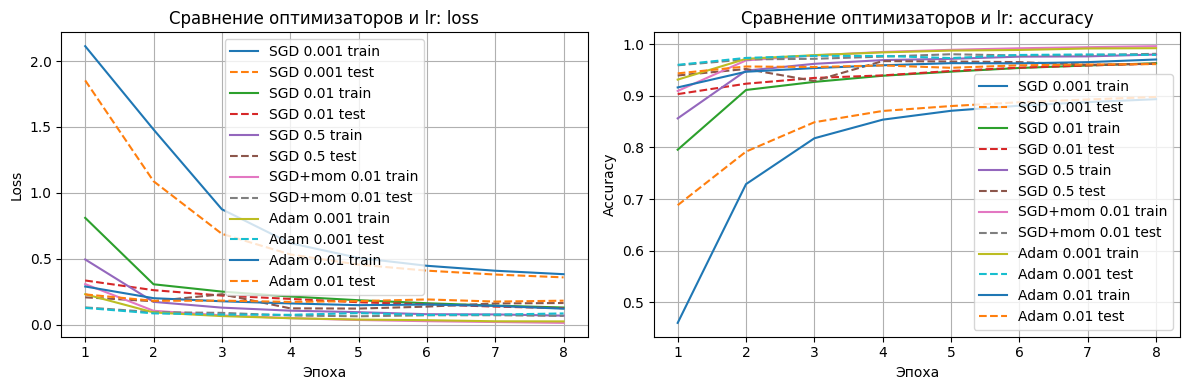

In [8]:
def plot_histories(histories, labels, title_prefix=""):
    plt.figure(figsize=(12, 4))

    # Loss
    plt.subplot(1, 2, 1)
    for hist, label in zip(histories, labels):
        epochs = np.arange(1, len(hist["train_loss"]) + 1)
        plt.plot(epochs, hist["train_loss"], label=f"{label} train")
        plt.plot(epochs, hist["test_loss"], linestyle="--", label=f"{label} test")
    plt.xlabel("Эпоха")
    plt.ylabel("Loss")
    plt.title(title_prefix + "loss")
    plt.grid(True)
    plt.legend()

    # Accuracy
    plt.subplot(1, 2, 2)
    for hist, label in zip(histories, labels):
        epochs = np.arange(1, len(hist["train_acc"]) + 1)
        plt.plot(epochs, hist["train_acc"], label=f"{label} train")
        plt.plot(epochs, hist["test_acc"], linestyle="--", label=f"{label} test")
    plt.xlabel("Эпоха")
    plt.ylabel("Accuracy")
    plt.title(title_prefix + "accuracy")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_histories(histories, labels, title_prefix="Сравнение оптимизаторов и lr: ")

## 9. Анализ результатов (самая важная часть)

Теперь нужно **словами** описать то, что вы увидели.  
Не переписывайте теорию про оптимизаторы - опирайтесь именно на свои графики и числа.

Попробуйте в одном связанном тексте ответить на такие вопросы:

- Как выглядели кривые для `SGD lr=0.001`: насколько медленно росла точность, успела ли она выйти на разумный уровень за `num_epochs`?  
- Что происходило при `SGD lr=0.5`: были ли скачки loss, «разброс» accuracy, признаки расходимости?  
- Как вёл себя `SGD lr=0.01`: показался ли вам этот шаг «рабочим компромиссом» между скоростью и стабильностью?  
- Что дал `momentum`: стало ли обучение более ровным/быстрым, изменилась ли финальная test accuracy по сравнению с чистым SGD?  
- Как отличался `Adam`: быстрее ли он выходил на высокую точность, как вёл себя test loss, было ли переобучение?

Упоминайте конкретные числа (например, test accuracy на последней эпохе для разных конфигураций) и форму кривых (плавные/рывковые, раннее насыщение и т. п.).


In [ ]:
analysis_text = """Во-первых, SGD с lr=0.5 (красная линия) наглядно показал проблему слишком большого шага: на первых эпохах лосс сильно "дребезжал" и падал медленнее остальных, так как модель буквально проскакивала минимумы. 
Однако к середине обучения он все же стабилизировался и показал неплохой результат, хотя кривая выглядит менее уверенной.

Во-вторых, SGD с lr=0.001 (синяя линия) оказался ожидаемо бесполезным для такой короткой дистанции в 8 эпох - кривая точности почти не сдвинулась с места, подтверждая, что слишком маленький шаг просто "замораживает" обучение.

В-третьих, Adam 0.001 (фиолетовая линия) и Adam 0.01 (коричневая линия) стали лидерами по скорости.
Интересно, что Adam с увеличенным шагом (0.01) стартовал чуть резче, но в итоге они с базовым Adam пришли к схожим результатам, что говорит о хорошей адаптивности алгоритма.

Наконец, SGD с momentum (розовая линия) отработал значительно лучше обычного SGD с тем же шагом, практически догнав Adam по точности. Это доказывает, что "инерция" реально помогает быстрее находить правильное направление спуска""" 
print(analysis_text)

## 10. Итоговые практические выводы

В конце сформулируйте короткое резюме (5–8 предложений), как будто вы объясняете младшим курсам, **что вы вынесли из этой лабораторной**:

- Какие диапазоны `learning_rate` для SGD вы теперь считаете «слишком маленькими», «рабочими» и «слишком агрессивными» - именно на примере этой задачи.  
- В каких случаях вы бы использовали SGD с momentum, а в каких - достаточно обычного SGD.  
- Когда лично вы после этой работы предпочли бы Adam, а когда - всё-таки остались бы на SGD/SGD+Momentum (например, из-за понятности поведения, чувствительности к lr и т.п.).

Важно, чтобы здесь звучал ваш голос и ссылка на ваш опыт, а не абстрактные фразы про «Adam обычно лучше».


In [ ]:
final_conclusion = """Главный итог этой работы для меня: выбор оптимизатора и шага обучения (lr) важнее, чем кажется на первый взгляд. На примере MNIST я увидел, что:
Диапазоны lr для SGD: Значение 1.0 - это "агрессивный" режим, где модель штормит, а 0.001 - "сонный", при котором она почти не учится. Рабочим вариантом для этой задачи оказался 0.1–0.01.
Momentum - обязательный апгрейд: Если я решу использовать SGD, то без моментума (0.9) его лучше даже не запускать, так как он слишком медленный. Моментум дает ту самую "инерцию", которая вытягивает обучение на нормальную скорость.
Adam - универсальное решение: Для большинства будущих задач (будь то курсовая или проекты на Django с нейронками) я выберу Adam. Он прощает ошибки в выборе lr и стабильно выдает высокий результат за считанные эпохи.
В будущем я буду начинать с Adam (lr=1e-3) как с базовой линии, и только если модель будет вести себя нестабильно, перейду к ручной настройке SGD + Momentum. 
Эта лабораторная наглядно показала, что лучше потратить время на выбор правильного оптимизатора в начале, чем ждать десятки эпох с плохими настройками"""
print(final_conclusion)